In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re
from wordcloud import WordCloud


/var/folders/g9/_yq754fd4036z7p0lpv64m3r0000gn/T/ipykernel_84492/2995907555.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  corn = pd.read_csv("cornell_combined.csv")


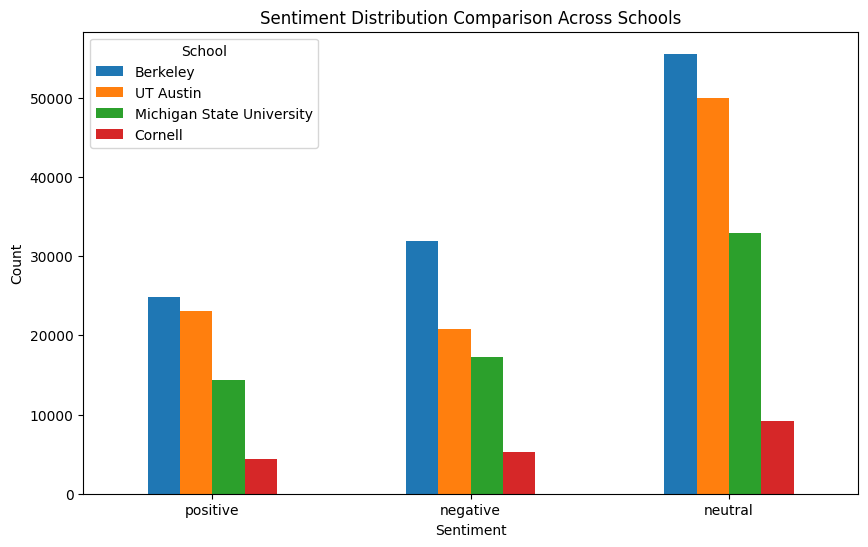

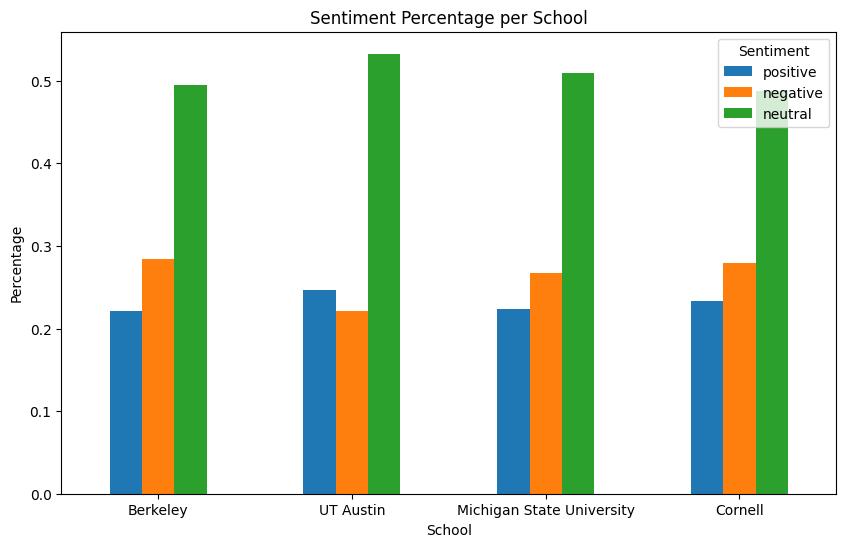

In [7]:
berk = pd.read_csv("berkeley_combined.csv") 
uta = pd.read_csv("uta_combined.csv")
msu = pd.read_csv("msu_combined.csv")
corn = pd.read_csv("cornell_combined.csv")

# 计算每个学校的情感分布
def sentiment_distribution(df, school_name):
    sentiment_counts = df['sentiment_label'].value_counts()
    plt.figure(figsize=(8, 5))
    sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
    plt.title(f'Sentiment Distribution for {school_name}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

def assign_sentiment(row):
    sentiments = {
        'positive': row['emo_pred_pos'],
        'negative': row['emo_pred_neg'],
        'neutral': row['emo_pred_neu'],
    }
    return max(sentiments, key=sentiments.get)

# 如果尚未有 sentiment_label，可以自动打标签（否则略过这一行）
if 'sentiment_label' not in berk.columns:
    berk['sentiment_label'] = berk.apply(assign_sentiment, axis=1)
if 'sentiment_label' not in uta.columns:
    uta['sentiment_label'] = uta.apply(assign_sentiment, axis=1)
if 'sentiment_label' not in msu.columns:
    msu['sentiment_label'] = msu.apply(assign_sentiment, axis=1)
if 'sentiment_label' not in corn.columns:
    corn['sentiment_label'] = corn.apply(assign_sentiment, axis=1)



# 绘制每个学校的情感分布
# 统计每个学校的情感分布
schools = {
    'Berkeley': berk,
    'UT Austin': uta,
    'Michigan State University': msu,
    'Cornell': corn
}

sentiments = ['positive', 'negative', 'neutral']
sentiment_counts = {school: df['sentiment_label'].value_counts() for school, df in schools.items()}

# 构建 DataFrame 以便绘图
sentiment_df = pd.DataFrame(sentiment_counts).reindex(sentiments).fillna(0)

# 绘制分组柱状图
sentiment_df.plot(kind='bar', figsize=(10, 6))
plt.title('Sentiment Distribution Comparison Across Schools')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='School')
plt.show()

# 计算每个学校的情感分布in percentage
sentiment_percentage = sentiment_df.div(sentiment_df.sum(axis=0), axis=1)
# # 绘制百分比堆叠柱状图
# sentiment_percentage.plot(kind='bar', stacked=True, figsize=(10, 6))
# plt.title('Sentiment Distribution Percentage Comparison Across Schools')
# plt.xlabel('Sentiment')
# plt.ylabel('Percentage')
# plt.xticks(rotation=0)
# plt.legend(title='School')
# plt.show()


sentiment_percentage.T.plot(kind='bar', figsize=(10, 6))
plt.title('Sentiment Percentage per School')
plt.xlabel('School')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

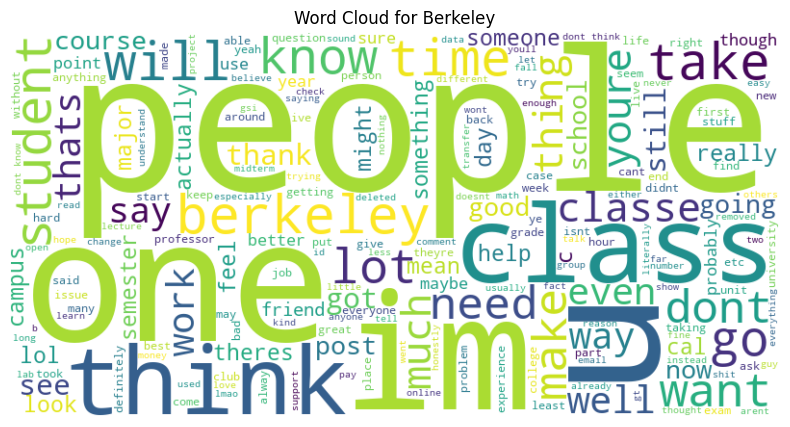

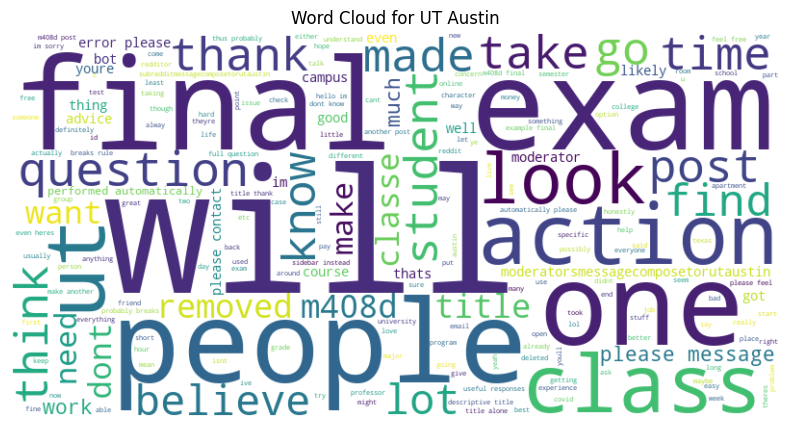

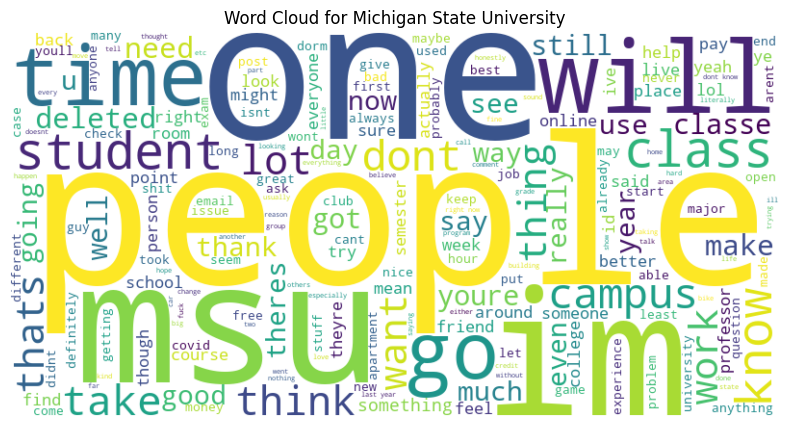

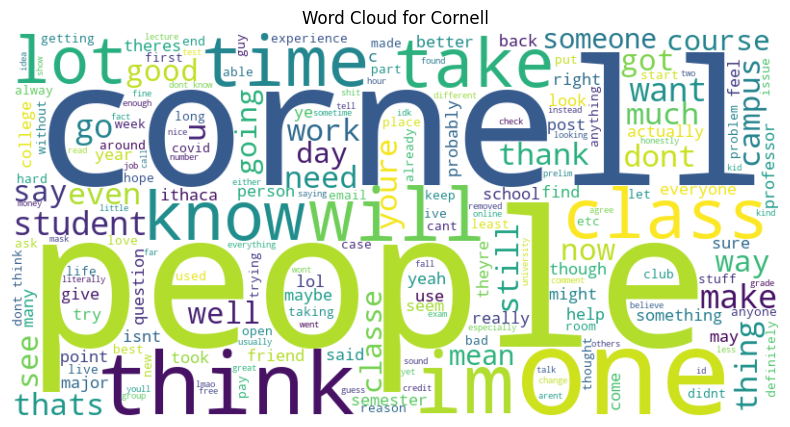

In [17]:
#generate word clouds for each school and compare them
def generate_wordcloud(df, school_name):
    text = ' '.join(df['body'].dropna().astype(str).tolist())
    text = re.sub(r'[^\w\s]', '', text)  # 移除标点符号
    text = text.lower()  # 转为小写
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {school_name}')
    plt.show()

# 生成每个学校的词云
for school, df in schools.items():
    generate_wordcloud(df, school)

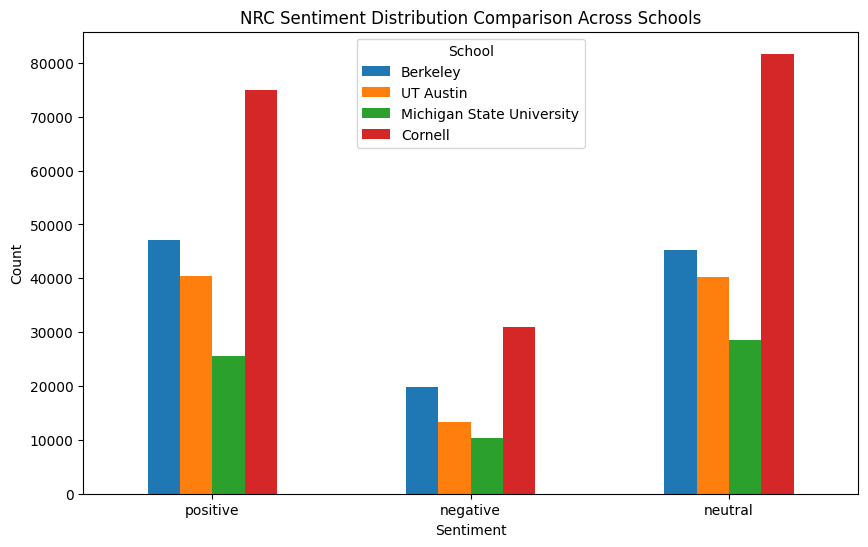

In [24]:
# 1. Load NRC lexicon
nrc_df = pd.read_csv("nrc_lexicon.txt", sep="\t", names=["word", "emotion", "association"])
nrc_df = nrc_df[nrc_df["association"] == 1]

# 2. Define which emotions are positive or negative
positive_emotions = {"joy", "trust", "anticipation", "surprise"}
negative_emotions = {"anger", "fear", "sadness", "disgust"}

# 3. Create emotion dictionary
from collections import defaultdict
nrc_emotion_dict = defaultdict(list)
for _, row in nrc_df.iterrows():
    nrc_emotion_dict[row["word"]].append(row["emotion"])

# 4. Assign sentiment to each row
import re

def assign_nrc_sentiment_from_text(text):
    pos = 0
    neg = 0
    words = re.findall(r'\b\w+\b', str(text).lower())
    for word in words:
        emotions = nrc_emotion_dict.get(word, [])
        for emo in emotions:
            if emo in positive_emotions:
                pos += 1
            elif emo in negative_emotions:
                neg += 1
    if pos > neg:
        return "positive"
    elif neg > pos:
        return "negative"
    else:
        return "neutral"
    
# 5. Apply to each DataFrame
berk['nrc_sentiment'] = berk['body'].apply(assign_nrc_sentiment_from_text)
uta['nrc_sentiment'] = uta['body'].apply(assign_nrc_sentiment_from_text)
msu['nrc_sentiment'] = msu['body'].apply(assign_nrc_sentiment_from_text)
corn['nrc_sentiment'] = corn['body'].apply(assign_nrc_sentiment_from_text)

# 6. Compare NRC sentiment distribution
nrc_sentiment_counts = {
    'Berkeley': berk['nrc_sentiment'].value_counts(),
    'UT Austin': uta['nrc_sentiment'].value_counts(),
    'Michigan State University': msu['nrc_sentiment'].value_counts(),
    'Cornell': corn['nrc_sentiment'].value_counts()
}
# 构建 DataFrame 以便绘图
nrc_sentiment_df = pd.DataFrame(nrc_sentiment_counts).reindex(['positive', 'negative', 'neutral']).fillna(0)
# 绘制分组柱状图
nrc_sentiment_df.plot(kind='bar', figsize=(10, 6))
plt.title('NRC Sentiment Distribution Comparison Across Schools')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='School')
plt.show()

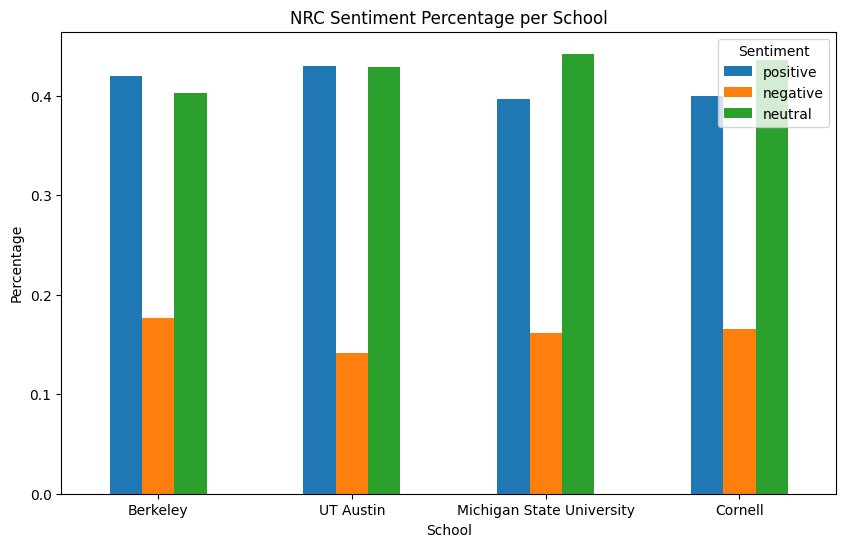

In [ ]:
# 计算每个学校的情感分布in percentage using NRC sentiment
nrc_sentiment_percentage = nrc_sentiment_df.div(nrc_sentiment_df.sum(axis=0), axis=1)
# 绘制百分比堆叠柱状图
nrc_sentiment_percentage.T.plot(kind='bar', figsize=(10, 6))
plt.title('NRC Sentiment Percentage per School')
plt.xlabel('School')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

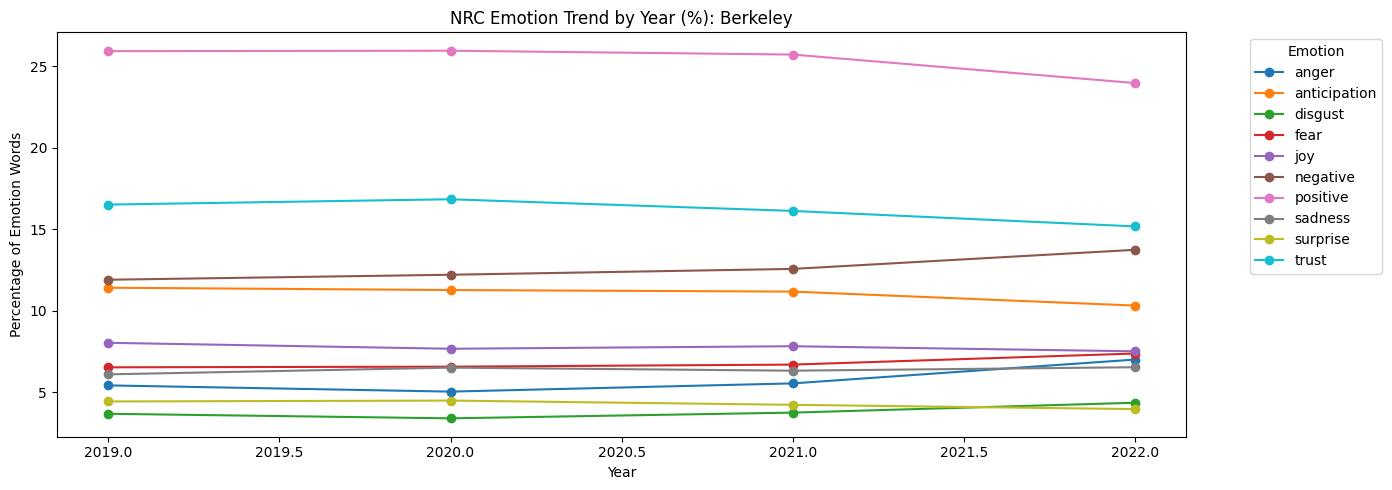

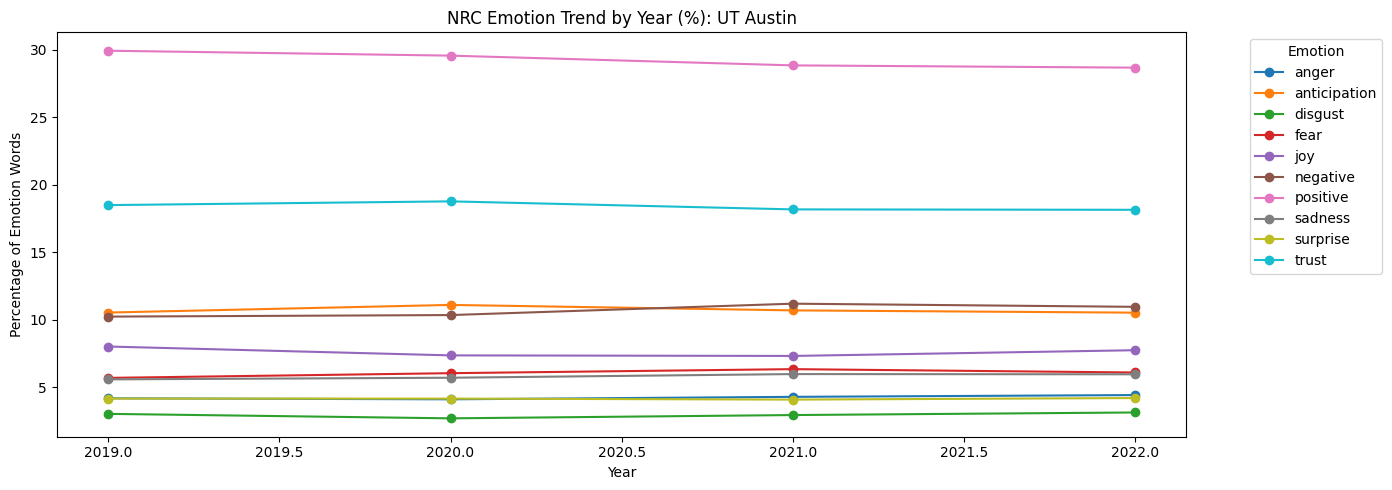

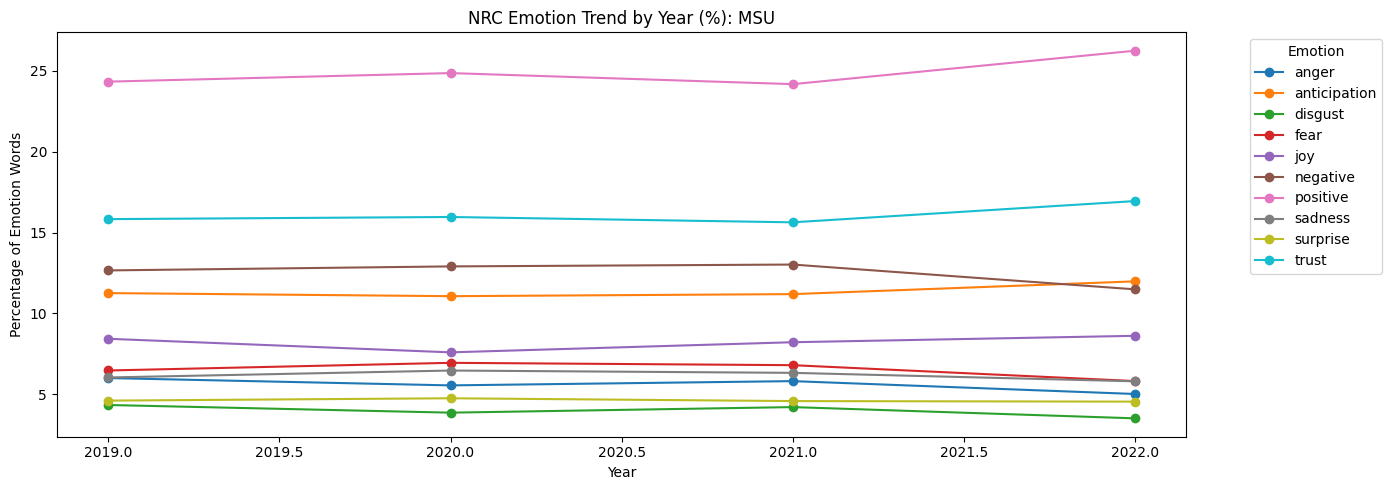

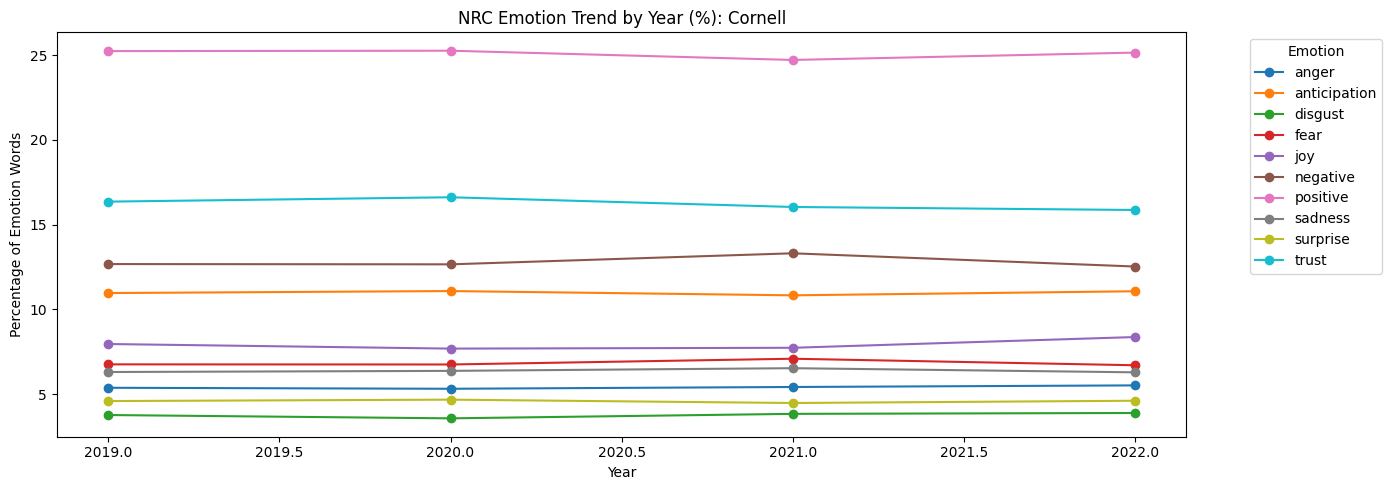

In [32]:
# Load NRC lexicon
nrc_df = pd.read_csv("nrc_lexicon.txt", sep="\t", names=["word", "emotion", "association"])
nrc_df = nrc_df[nrc_df["association"] == 1]

# Build dictionary: word → list of emotions
nrc_emotion_dict = defaultdict(list)
for _, row in nrc_df.iterrows():
    nrc_emotion_dict[row["word"]].append(row["emotion"])

# Define schools dictionary (make sure df has 'year' and 'body' columns)
schools = {
    'Berkeley': berk,
    'UT Austin': uta,
    'MSU': msu,
    'Cornell': corn
}

# Store results in a multi-index DataFrame: (School, Year) × Emotion
results = []

for school_name, school_df in schools.items():
    for _, row in school_df.iterrows():
        year = row['year']
        words = re.findall(r'\b\w+\b', str(row['body']).lower())
        emotions_this_post = Counter()
        for word in words:
            if word in nrc_emotion_dict:
                emotions_this_post.update(nrc_emotion_dict[word])
        
        for emotion, count in emotions_this_post.items():
            results.append((school_name, year, emotion, count))

# Convert to DataFrame
emotion_df = pd.DataFrame(results, columns=["school", "year", "emotion", "count"])

# Pivot: index=(school, year), columns=emotion
pivot_df = emotion_df.pivot_table(
    index=["school", "year"],
    columns="emotion",
    values="count",
    aggfunc="sum"
).fillna(0)

# Compute percentage by row (row = a school's year)
emotion_pct_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Plot per school
for school in schools:
    school_df = emotion_pct_df.loc[school]
    ax = school_df.sort_index().plot(kind="line", marker='o', figsize=(14, 5))
    plt.title(f"NRC Emotion Trend by Year (%): {school}")
    plt.xlabel("Year")
    plt.ylabel("Percentage of Emotion Words")
    plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()